# Step 6 — Summary Table

Pulls together every prior step's results into one place: annual demand, connected load, system size, battery size, cost, and LCOE — plus **ROI and payback period**, which don't exist anywhere in the source workbook (flagged as an open item back in `docs/PROJECT_LOG.md`) and are built from scratch here. Because that's new territory with a real assumption behind it (an electricity tariff — the source workbook has no revenue model at all, only cost), it gets its own section with the assumption stated plainly before any number is produced.

## 6.1 Setup — loading every prior step's results

In [1]:
import pandas as pd  # pandas: tabular data (DataFrames)
import numpy as np  # numpy: numerical operations
from pathlib import Path  # Path: OS-independent file paths

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

# Step 1
connected_load = pd.read_csv(DATA_DIR / "connected_load_results.csv").set_index("result")["value"]
# Step 2/3
hourly_profile = pd.read_csv(DATA_DIR / "hourly_load_profile_2026.csv")
annual_demand_wh = hourly_profile["total_wh"].sum()
# Step 4
pv_battery_results = pd.read_csv(DATA_DIR / "pv_battery_sizing_results_2026.csv").set_index("result")["value"]
pv_parameters = pd.read_csv(DATA_DIR / "default_pv_parameters.csv").set_index("parameter")["value"]
# Step 5
cost_lcoe_results = pd.read_csv(DATA_DIR / "cost_lcoe_results_2026.csv").set_index("result")["value"]
cost_parameters = pd.read_csv(DATA_DIR / "default_cost_parameters.csv")


def _coerce_numeric(value):
    """CSV round-tripping loses dtypes — a 'value' column mixing numbers and strings (like 'govt_lease') comes back
    as all-strings. Convert anything that parses as a number back to one; leave genuine strings (like 'govt_lease') alone."""
    try:
        return float(value) if not isinstance(value, (int, float)) else value
    except (TypeError, ValueError):
        return value


cost_parameters["value"] = cost_parameters["value"].apply(_coerce_numeric)  # apply(): fix the mixed-type column read back from CSV

print(f"Connected load:      {connected_load['total_connected_load_mw']:.5f} MW")
print(f"Annual demand:        {annual_demand_wh/1e9:.6f} GWh")
print(f"Ppeak (PV size):       {pv_parameters['ppeak_w']/1e6:.2f} MW")
print(f"Battery size:          {pv_battery_results['battery_capacity_kwh']:,.0f} kWh")
print(f"Zero-yield hours:      {pv_battery_results['zero_yield_hours']:.0f} h/year")
print(f"Capital cost:          {cost_lcoe_results['capital_cost_pkr']:,.0f} PKR")
print(f"Total cost (Capex+Opex): {cost_lcoe_results['total_cost_pkr']:,.0f} PKR")
print(f"LCOE:                  {cost_lcoe_results['lcoe_pkr_per_kwh']:.4f} PKR/kWh")

Connected load:      1.81128 MW
Annual demand:        3.440338 GWh
Ppeak (PV size):       2.00 MW
Battery size:          8,000 kWh
Zero-yield hours:      317 h/year
Capital cost:          604,000,000 PKR
Total cost (Capex+Opex): 1,123,857,391 PKR
LCOE:                  9.7562 PKR/kWh


## 6.2 ROI and payback period — built from scratch, with the assumption stated up front

**The source workbook has no revenue model at all** — it only ever computes cost (LCOE). ROI and payback period are fundamentally about comparing money coming in against money going out, so this needs one new assumption the workbook never makes: **what this electricity is worth** — either a tariff charged to the households, or the cost this project avoids (e.g., diesel generator fuel, or a grid-extension alternative) if it isn't sold directly.

Rather than inventing a number and presenting it as fact, `electricity_tariff_pkr_per_kwh` below defaults to **exactly the computed LCOE** — i.e., break-even, 0% margin. That's a deliberately neutral placeholder, not a researched market rate for this site. **This is the one input in the whole app you should replace with a real planning assumption** (an actual planned tariff, or subsidy value, or avoided-cost figure) — everything downstream (payback period, ROI, NPV) moves directly off of it.

Methodology (standard project-finance definitions, nothing site-specific):
- **Annual revenue** = energy served (kWh/year) × tariff, escalating at an editable annual rate (default 0%).
- **Annual cost** = the O&M+insurance cash flow from Step 5 (already inflating at 8%/yr) + land lease spread evenly across the years, with the battery and inverter replacement costs hitting as one-time outflows in the year they occur (default: year 12, matching the source workbook's own assumption).
- **Simple payback** = the year the running total of (revenue − cost), undiscounted, first covers the initial capital cost.
- **Discounted payback / NPV / ROI** = the same, but each year's net cash flow is discounted at the same 10% discount rate Step 5 already uses.

In [2]:
default_roi_parameters = pd.DataFrame([
    {"parameter": "electricity_tariff_pkr_per_kwh", "value": cost_lcoe_results["lcoe_pkr_per_kwh"], "unit": "PKR/kWh",
     "description": "PLACEHOLDER — defaults to break-even (= LCOE). Replace with a real planned tariff or avoided-cost figure for a meaningful ROI."},
    {"parameter": "revenue_escalation_rate", "value": 0.0, "unit": "fraction/year", "description": "Annual growth rate applied to the tariff/revenue (0 = flat)"},
    {"parameter": "replacement_year", "value": 12, "unit": "year", "description": "Year the battery and inverter replacement costs hit as a one-time outflow"},
])
default_roi_parameters.to_csv(DATA_DIR / "default_roi_parameters.csv", index=False)
print("Saved to:", (DATA_DIR / "default_roi_parameters.csv").resolve())
default_roi_parameters

Saved to: /home/claude/rural-electrification/data/default_roi_parameters.csv


,parameter,value,unit,description
0,electricity_tariff_pkr_per_kwh,9.756155,PKR/kWh,PLACEHOLDER — defaults to break-even (= LCOE)....
1,revenue_escalation_rate,0.000000,fraction/year,Annual growth rate applied to the tariff/reven...
2,replacement_year,12.000000,year,Year the battery and inverter replacement cost...


In [3]:
def get_param(parameters_df: pd.DataFrame, name: str):
    """Look up one parameter's value by name — same small helper used in Steps 4 and 5."""
    return parameters_df.loc[parameters_df["parameter"] == name, "value"].iloc[0]


def compute_om_cash_flow(capital_cost_pkr, insurance_pct, om_usd_per_kw, ppeak_kw, usd_to_pkr_rate, inflation_rate, years=30):
    """Year-by-year nominal O&M+insurance cash flow (PKR) — same formula as Step 5's compute_om_present_value(), restated
    here so this notebook doesn't depend on re-running Step 5's cells to get the yearly (not just total) series."""
    cfo_year1 = insurance_pct * capital_cost_pkr + om_usd_per_kw * ppeak_kw * usd_to_pkr_rate
    years_arr = np.arange(1, years + 1)
    return cfo_year1 * (1 + inflation_rate) ** (years_arr - 1)


def simulate_project_cashflow(capital_cost_pkr: float, annual_energy_served_kwh: float, battery_capex_pkr: float,
                               inverter_replacement_pkr: float, land_annual_cost_pkr: float,
                               om_cash_flow_by_year: np.ndarray, roi_parameters_df: pd.DataFrame, discount_rate: float,
                               years: int = 30) -> dict:
    """
    Build the full year-by-year project cash flow and derive simple payback, discounted payback, NPV, and lifetime ROI.
    Returns a dict with the yearly DataFrame plus the four summary figures (payback figures are None if never reached).
    """
    tariff = get_param(roi_parameters_df, "electricity_tariff_pkr_per_kwh")
    escalation = get_param(roi_parameters_df, "revenue_escalation_rate")
    replacement_year = int(get_param(roi_parameters_df, "replacement_year"))

    years_arr = np.arange(1, years + 1)
    revenue = annual_energy_served_kwh * tariff * (1 + escalation) ** (years_arr - 1)  # escalate the tariff forward each year
    replacement_cost = np.where(years_arr == replacement_year, battery_capex_pkr + inverter_replacement_pkr, 0.0)  # where(): a one-time cost only in the replacement year, 0 elsewhere
    net_cash_flow = revenue - om_cash_flow_by_year - land_annual_cost_pkr - replacement_cost

    cumulative_nominal = np.cumsum(net_cash_flow) - capital_cost_pkr  # cumsum(): running total, starting from -capital_cost_pkr at year 0
    discounted_cash_flow = net_cash_flow / (1 + discount_rate) ** years_arr
    cumulative_discounted = np.cumsum(discounted_cash_flow) - capital_cost_pkr

    yearly = pd.DataFrame({
        "year": years_arr, "revenue_pkr": revenue, "om_cost_pkr": om_cash_flow_by_year, "land_cost_pkr": land_annual_cost_pkr,
        "replacement_cost_pkr": replacement_cost, "net_cash_flow_pkr": net_cash_flow,
        "cumulative_nominal_pkr": cumulative_nominal, "cumulative_discounted_pkr": cumulative_discounted,
    })

    def _first_crossing_year(cumulative: np.ndarray):
        """Interpolate the fractional year cumulative cash flow first reaches 0, or None if it never does within `years`."""
        positive = np.where(cumulative >= 0)[0]  # where(): indices of every year already break-even or better
        if len(positive) == 0:
            return None
        i = positive[0]  # the first such year (0-indexed -> year i+1)
        if i == 0:
            return 1.0
        prev, curr = cumulative[i - 1], cumulative[i]  # interpolate between the last negative year and this first non-negative year
        return i + (-prev) / (curr - prev)

    simple_payback_years = _first_crossing_year(cumulative_nominal)
    discounted_payback_years = _first_crossing_year(cumulative_discounted)
    npv_pkr = cumulative_discounted[-1]  # the final year's cumulative discounted cash flow IS the project's NPV
    roi_pct = (net_cash_flow.sum() - capital_cost_pkr) / capital_cost_pkr * 100  # simple lifetime ROI: (total nominal net cash - capex) / capex

    return {"yearly": yearly, "simple_payback_years": simple_payback_years, "discounted_payback_years": discounted_payback_years,
            "npv_pkr": npv_pkr, "roi_pct": roi_pct}

### Running it, at the break-even default and at an illustrative real tariff

First at the default placeholder (tariff = LCOE) — expect roughly break-even, likely *never* fully paying back within 30 years, since the tariff is calibrated to generation-based LCOE while revenue here is earned on demand *served* (lower than generation) minus zero-yield-hour shortfalls not even subtracted here — see the note below. Then at an illustrative +50% tariff, just to confirm the mechanism actually responds — **not** a claim about what a real tariff should be.

In [4]:
def get_boq_land_battery(cost_parameters_df: pd.DataFrame) -> dict:
    """Recompute the few extra pieces (battery capex, inverter replacement, land annual cost) run_cost_lcoe_pipeline()
    in Step 5 already derives internally, needed again here for the year-by-year cash flow (Step 5 only saved the totals)."""
    battery_capacity_kwh = pv_battery_results["battery_capacity_kwh"]
    battery_capex_pkr = (battery_capacity_kwh / 1000) * get_param(cost_parameters_df, "battery_unit_cost_pkr_per_mwh")
    inverter_replacement_pkr = get_param(cost_parameters_df, "inverter_replacement_pct") * (cost_lcoe_results["capital_cost_pkr"] - battery_capex_pkr)
    land_cost_options = pd.read_csv(DATA_DIR / "default_land_cost_options.csv")
    land_approach = get_param(cost_parameters_df, "land_cost_approach")
    land_total_pkr = 0 if land_approach in ("none", "buy") else land_cost_options.loc[land_cost_options["approach"] == land_approach, "total_cost_pkr"].iloc[0]
    years = int(get_param(cost_parameters_df, "project_lifetime_years"))
    return {"battery_capex_pkr": battery_capex_pkr, "inverter_replacement_pkr": inverter_replacement_pkr, "land_annual_cost_pkr": land_total_pkr / years, "years": years}


_extras = get_boq_land_battery(cost_parameters)
_om_cash_flow = compute_om_cash_flow(cost_lcoe_results["capital_cost_pkr"], get_param(cost_parameters, "insurance_pct_per_year"),
                                      get_param(cost_parameters, "om_usd_per_kw_per_year"), pv_parameters["ppeak_w"] / 1000,
                                      get_param(cost_parameters, "usd_to_pkr_rate"), get_param(cost_parameters, "inflation_rate"), years=_extras["years"])
_annual_energy_served_kwh = annual_demand_wh / 1000  # simplification, noted above: treats all demand as served (doesn't subtract the ~317 zero-yield hours' worth of shortfall)

# Run 1: default (break-even) tariff
cashflow_default = simulate_project_cashflow(cost_lcoe_results["capital_cost_pkr"], _annual_energy_served_kwh,
                                              _extras["battery_capex_pkr"], _extras["inverter_replacement_pkr"], _extras["land_annual_cost_pkr"],
                                              _om_cash_flow, default_roi_parameters, get_param(cost_parameters, "discount_rate"), years=_extras["years"])
print("=== Default (tariff = LCOE, break-even placeholder) ===")
print(f"NPV:               {cashflow_default['npv_pkr']:,.0f} PKR")
print(f"Lifetime ROI:      {cashflow_default['roi_pct']:.1f}%")
print(f"Simple payback:    {cashflow_default['simple_payback_years']}")
print(f"Discounted payback: {cashflow_default['discounted_payback_years']}")

# Run 2: illustrative +50% tariff, purely to show the mechanism responds
_illustrative_params = default_roi_parameters.copy()
_illustrative_params.loc[_illustrative_params["parameter"] == "electricity_tariff_pkr_per_kwh", "value"] *= 1.5
cashflow_illustrative = simulate_project_cashflow(cost_lcoe_results["capital_cost_pkr"], _annual_energy_served_kwh,
                                                   _extras["battery_capex_pkr"], _extras["inverter_replacement_pkr"], _extras["land_annual_cost_pkr"],
                                                   _om_cash_flow, _illustrative_params, get_param(cost_parameters, "discount_rate"), years=_extras["years"])
print()
print(f"=== Illustrative (+50% tariff = {get_param(_illustrative_params, 'electricity_tariff_pkr_per_kwh'):.4f} PKR/kWh) ===")
print(f"NPV:               {cashflow_illustrative['npv_pkr']:,.0f} PKR")
print(f"Lifetime ROI:      {cashflow_illustrative['roi_pct']:.1f}%")
print(f"Simple payback:    {cashflow_illustrative['simple_payback_years']:.1f} years" if cashflow_illustrative['simple_payback_years'] else "Simple payback:    never within 30 years")
print(f"Discounted payback: {cashflow_illustrative['discounted_payback_years']:.1f} years" if cashflow_illustrative['discounted_payback_years'] else "Discounted payback: never within 30 years")

=== Default (tariff = LCOE, break-even placeholder) ===
NPV:               -511,307,349 PKR
Lifetime ROI:      -80.8%
Simple payback:    None
Discounted payback: None

=== Illustrative (+50% tariff = 14.6342 PKR/kWh) ===
NPV:               -353,102,652 PKR
Lifetime ROI:      2.6%
Simple payback:    28.8 years
Discounted payback: never within 30 years


In [5]:
# The default scenario's tariff is set to break even against Step 5's LCOE, yet it shows NPV well below zero and never
# pays back. That's not a bug — it's two real accounting-basis differences between Step 5's LCOE and this cash-flow
# model, both quantified below.
_discount_rate = get_param(cost_parameters, "discount_rate")
_om_pv = (_om_cash_flow / (1 + _discount_rate) ** np.arange(1, _extras["years"] + 1)).sum()  # what Step 5's LCOE actually charged for O&M
_generation_kwh_total = pv_battery_results["annual_egen_wh"] / 1000 * _extras["years"]  # LCOE's own energy basis (generation, not demand)
_tariff = get_param(default_roi_parameters, "electricity_tariff_pkr_per_kwh")
_generation_based_revenue = _generation_kwh_total * _tariff
_demand_based_revenue = _annual_energy_served_kwh * _extras["years"] * _tariff
_nominal_om_sum = _om_cash_flow.sum()
_npv_gap = cashflow_default["npv_pkr"]
_capex = cost_lcoe_results["capital_cost_pkr"]

print("Why tariff = LCOE isn't actually break-even here:")
print("1) O&M, full nominal 8%/yr-escalating sum (this cash-flow model uses): {:>15,.0f} PKR".format(_nominal_om_sum))
print("   O&M, present value (what Step 5's LCOE actually charged for):      {:>15,.0f} PKR".format(_om_pv))
print("   -> extra nominal O&M cost the LCOE-based tariff was never asked to cover: {:,.0f} PKR".format(_nominal_om_sum - _om_pv))
print()
print("2) Revenue if billed on generation (LCOE's own energy basis):  {:>15,.0f} PKR".format(_generation_based_revenue))
print("   Revenue actually billed, on demand served:                 {:>15,.0f} PKR".format(_demand_based_revenue))
print("   -> shortfall (tariff assumes energy sold that isn't):      {:,.0f} PKR".format(_generation_based_revenue - _demand_based_revenue))
print()
_effect_sum = (_nominal_om_sum - _om_pv) + (_generation_based_revenue - _demand_based_revenue)
print("Sum of both effects: {:,.0f} PKR".format(_effect_sum))
print("(compare to the default scenario's NPV of {:,.0f} PKR against {:,.0f} PKR of capex)".format(_npv_gap, _capex))

Why tariff = LCOE isn't actually break-even here:
1) O&M, full nominal 8%/yr-escalating sum (this cash-flow model uses):     456,304,774 PKR
   O&M, present value (what Step 5's LCOE actually charged for):           85,257,391 PKR
   -> extra nominal O&M cost the LCOE-based tariff was never asked to cover: 371,047,383 PKR

2) Revenue if billed on generation (LCOE's own energy basis):    1,123,857,391 PKR
   Revenue actually billed, on demand served:                   1,006,934,122 PKR
   -> shortfall (tariff assumes energy sold that isn't):      116,923,270 PKR

Sum of both effects: 487,970,653 PKR
(compare to the default scenario's NPV of -511,307,349 PKR against 604,000,000 PKR of capex)


**Reading this**: Step 5's LCOE is a simplified, blended levelized figure — it discounts O&M to a present value but leaves capex, battery/inverter replacement, and land undiscounted, then divides by *generation* (not demand). That's a perfectly standard way to compute a cost-of-energy figure, and it's exactly what the source workbook does. But it is **not** the same thing as "the tariff at which this project's real, full year-by-year cash flow breaks even" — this cash-flow model uses the full nominal (escalating, undiscounted-until-the-final-NPV-step) O&M series, and only earns revenue on energy actually demanded, not everything generated. Both are legitimate views; they just don't agree by coincidence.

**Practical takeaway**: don't read too much into the default scenario's negative NPV — it's an artifact of using LCOE as a stand-in tariff, not a statement that the project loses money. Replace `electricity_tariff_pkr_per_kwh` in `default_roi_parameters` (or the uploaded template, see §6.5) with your actual intended tariff, subsidy, or avoided-cost figure to get a meaningful answer. The **+50% tariff** run above (≈14.63 PKR/kWh) is a closer illustration of what a genuinely profitable tariff looks like at this system size: positive lifetime ROI, a finite simple payback — though still no discounted payback within 30 years, since the 10% discount rate is demanding.

## 6.3 Cumulative cash flow, over the 30-year project life

In [6]:
import matplotlib.pyplot as plt  # matplotlib: charting
import matplotlib.ticker as mticker  # mticker: custom axis tick formatting
%matplotlib inline
# inline backend: renders charts directly beneath the cell instead of a separate window, which is what was hanging
# earlier notebooks when it was missing.

# Same validated chrome/category palette used in every chart across this project (see docs/PROJECT_LOG.md).
CATEGORY_COLORS = {"A": "#2a78d6", "B": "#eb6834", "C": "#1baf7a", "Misc": "#eda100"}
GRIDLINE, AXIS_INK, TEXT_PRIMARY, TEXT_MUTED = "#e1e0d9", "#c3c2b7", "#0b0b0b", "#898781"


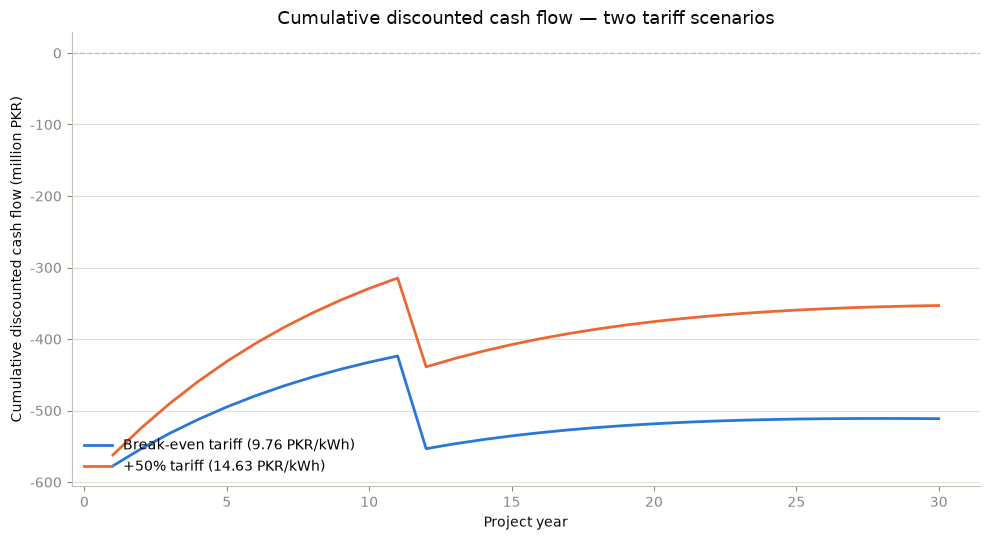

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))

# Two scenarios, cumulative discounted cash flow (the NPV trajectory) — shows visually why one never crosses zero
# and the other does.
ax.plot(cashflow_default["yearly"]["year"], cashflow_default["yearly"]["cumulative_discounted_pkr"] / 1e6,
        color=CATEGORY_COLORS["A"], linewidth=2, label=f"Break-even tariff ({_tariff:.2f} PKR/kWh)")
ax.plot(cashflow_illustrative["yearly"]["year"], cashflow_illustrative["yearly"]["cumulative_discounted_pkr"] / 1e6,
        color=CATEGORY_COLORS["B"], linewidth=2, label=f"+50% tariff ({get_param(_illustrative_params, 'electricity_tariff_pkr_per_kwh'):.2f} PKR/kWh)")
ax.axhline(0, color=AXIS_INK, linewidth=1, linestyle="--")  # break-even line

# Mark the illustrative scenario's discounted-payback year, if it reached one within 30 years.
_dpy = cashflow_illustrative["discounted_payback_years"]
if _dpy is not None:
    ax.plot(_dpy, 0, marker="o", color=CATEGORY_COLORS["B"], markersize=8, zorder=5)
    ax.annotate(f"discounted payback: {_dpy:.1f} yr", xy=(_dpy, 0), xytext=(_dpy - 5, 60),
                fontsize=9, color=TEXT_PRIMARY, arrowprops=dict(arrowstyle="->", color=TEXT_MUTED))

ax.set_xlabel("Project year", color=TEXT_PRIMARY)
ax.set_ylabel("Cumulative discounted cash flow (million PKR)", color=TEXT_PRIMARY)
ax.set_title("Cumulative discounted cash flow — two tariff scenarios", color=TEXT_PRIMARY, fontsize=13)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(AXIS_INK)
ax.tick_params(colors=TEXT_MUTED)
ax.grid(axis="y", color=GRIDLINE, linewidth=0.8)
ax.legend(frameon=False, loc="lower left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig(DATA_DIR.parent / "notebooks" / "_cashflow_chart_2026.png", dpi=120, bbox_inches="tight")  # saved alongside the notebook for reuse (e.g. in the Streamlit app)
plt.show()

## 6.4 Master summary — every step's key result, in one table

In [8]:
def convert_currency(pkr_value, currency, eur_to_pkr_rate, usd_to_pkr_rate):
    """Same small helper as Step 5, restated here for this notebook's self-containment."""
    rates = {"PKR": 1.0, "EUR": eur_to_pkr_rate, "USD": usd_to_pkr_rate}
    return pkr_value / rates[currency]


_eur_rate = get_param(cost_parameters, "eur_to_pkr_rate")
_usd_rate = get_param(cost_parameters, "usd_to_pkr_rate")

master_summary = pd.DataFrame([
    {"section": "Load", "metric": "Total connected load", "value": connected_load["total_connected_load_mw"], "unit": "MW"},
    {"section": "Load", "metric": "Annual demand (corrected calendar)", "value": annual_demand_wh / 1e9, "unit": "GWh/year"},
    {"section": "PV / Battery", "metric": "PV array size (Ppeak)", "value": pv_parameters["ppeak_w"] / 1e6, "unit": "MW"},
    {"section": "PV / Battery", "metric": "Annual generation (Egen)", "value": pv_battery_results["annual_egen_wh"] / 1e9, "unit": "GWh/year"},
    {"section": "PV / Battery", "metric": "Battery capacity", "value": pv_battery_results["battery_capacity_kwh"], "unit": "kWh"},
    {"section": "PV / Battery", "metric": "Zero-yield hours", "value": pv_battery_results["zero_yield_hours"], "unit": "h/year"},
    {"section": "Cost", "metric": "Capital cost (Capex)", "value": cost_lcoe_results["capital_cost_pkr"], "unit": "PKR"},
    {"section": "Cost", "metric": "Capital cost (Capex)", "value": convert_currency(cost_lcoe_results["capital_cost_pkr"], "USD", _eur_rate, _usd_rate), "unit": "USD"},
    {"section": "Cost", "metric": "Total Opex (30yr, present value basis)", "value": cost_lcoe_results["total_opex_pkr"], "unit": "PKR"},
    {"section": "Cost", "metric": "Total cost (Capex+Opex)", "value": cost_lcoe_results["total_cost_pkr"], "unit": "PKR"},
    {"section": "Cost", "metric": "LCOE (generation-based)", "value": cost_lcoe_results["lcoe_pkr_per_kwh"], "unit": "PKR/kWh"},
    {"section": "ROI (break-even placeholder tariff)", "metric": "Tariff used", "value": _tariff, "unit": "PKR/kWh"},
    {"section": "ROI (break-even placeholder tariff)", "metric": "NPV", "value": cashflow_default["npv_pkr"], "unit": "PKR"},
    {"section": "ROI (break-even placeholder tariff)", "metric": "Lifetime ROI", "value": cashflow_default["roi_pct"], "unit": "%"},
    {"section": "ROI (illustrative +50% tariff)", "metric": "Tariff used", "value": get_param(_illustrative_params, "electricity_tariff_pkr_per_kwh"), "unit": "PKR/kWh"},
    {"section": "ROI (illustrative +50% tariff)", "metric": "NPV", "value": cashflow_illustrative["npv_pkr"], "unit": "PKR"},
    {"section": "ROI (illustrative +50% tariff)", "metric": "Lifetime ROI", "value": cashflow_illustrative["roi_pct"], "unit": "%"},
    {"section": "ROI (illustrative +50% tariff)", "metric": "Simple payback", "value": cashflow_illustrative["simple_payback_years"], "unit": "years"},
])
master_summary.to_csv(DATA_DIR / "master_summary_2026.csv", index=False)
print("Saved to:", (DATA_DIR / "master_summary_2026.csv").resolve())
master_summary

Saved to: /home/claude/rural-electrification/data/master_summary_2026.csv


,section,metric,value,unit
0,Load,Total connected load,1.811280e+00,MW
1,Load,Annual demand (corrected calendar),3.440338e+00,GWh/year
2,PV / Battery,PV array size (Ppeak),2.000000e+00,MW
3,PV / Battery,Annual generation (Egen),3.839823e+00,GWh/year
4,PV / Battery,Battery capacity,8.000000e+03,kWh
5,PV / Battery,Zero-yield hours,3.170000e+02,h/year
6,Cost,Capital cost (Capex),6.040000e+08,PKR
7,Cost,Capital cost (Capex),2.157143e+06,USD
8,Cost,"Total Opex (30yr, present value basis)",5.198574e+08,PKR
9,Cost,Total cost (Capex+Opex),1.123857e+09,PKR


## 6.5 ROI parameters — Excel upload/download

Same validated export/import/round-trip pattern used for every other editable dataset in this project (Steps 2, 4, 5).

In [9]:
def export_roi_template(roi_parameters_df: pd.DataFrame, output_path) -> None:
    """Write the ROI parameters (tariff, escalation, replacement year) to one formatted .xlsx template."""
    with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
        workbook = writer.book
        header_fmt = workbook.add_format({"bold": True, "bg_color": "#2a78d6", "font_color": "white", "border": 1})

        instructions = pd.DataFrame({"Instructions": [
            "Edit the 'value' column only — do not add/remove/rename rows.",
            "electricity_tariff_pkr_per_kwh defaults to break-even (= LCOE) as a placeholder. Replace it with a real planned tariff, subsidy, or avoided-cost figure for a meaningful ROI.",
            "Save the file, then re-upload it in the app to use these values instead of the defaults.",
        ]})
        instructions.to_excel(writer, sheet_name="Instructions", index=False)
        roi_parameters_df.to_excel(writer, sheet_name="ROI Parameters", index=False)

        for sheet_name, df in [("Instructions", instructions), ("ROI Parameters", roi_parameters_df)]:
            ws = writer.sheets[sheet_name]
            for col_idx, col_name in enumerate(df.columns):
                ws.write(0, col_idx, col_name, header_fmt)
                ws.set_column(col_idx, col_idx, max(14, len(str(col_name)) + 2))


def import_roi_template(input_path) -> dict:
    """Read a workbook in the export_roi_template() shape back into the table, with validation."""
    errors = []
    sheets = pd.read_excel(input_path, sheet_name=None)
    if "ROI Parameters" not in sheets:
        return {"roi_parameters": None, "errors": ["Missing required sheet: 'ROI Parameters'"]}

    roi_parameters = sheets["ROI Parameters"]
    if set(roi_parameters.get("parameter", [])) != set(default_roi_parameters["parameter"]):
        errors.append("'ROI Parameters' must contain exactly the same parameter rows as the default")
    _tariff_val = roi_parameters.loc[roi_parameters["parameter"] == "electricity_tariff_pkr_per_kwh", "value"]
    if not _tariff_val.empty and _tariff_val.iloc[0] <= 0:
        errors.append("electricity_tariff_pkr_per_kwh must be positive")

    if errors:
        return {"roi_parameters": None, "errors": errors}
    return {"roi_parameters": roi_parameters, "errors": []}


export_roi_template(default_roi_parameters, DATA_DIR / "ROI_Parameters_Template.xlsx")
print("Saved to:", (DATA_DIR / "ROI_Parameters_Template.xlsx").resolve())

_imported = import_roi_template(DATA_DIR / "ROI_Parameters_Template.xlsx")
assert _imported["errors"] == [], f"Round-trip import reported errors: {_imported['errors']}"
pd.testing.assert_frame_equal(_imported["roi_parameters"].reset_index(drop=True), default_roi_parameters.reset_index(drop=True))
print("Round-trip OK: exported defaults re-imported with zero errors and an exact match.")

Saved to: /home/claude/rural-electrification/data/ROI_Parameters_Template.xlsx


Round-trip OK: exported defaults re-imported with zero errors and an exact match.


## 6.6 Project Summary Report — one Excel file with everything

The single deliverable this step was named for: every prior step's key results, plus both ROI scenarios' full 30-year cash flow, in one formatted workbook.

In [10]:
def export_project_summary_report(master_summary_df, cashflow_default_yearly, cashflow_illustrative_yearly,
                                    roi_parameters_df, output_path) -> None:
    """Consolidate every step's key results into one formatted .xlsx — the project's headline deliverable."""
    with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
        workbook = writer.book
        header_fmt = workbook.add_format({"bold": True, "bg_color": "#2a78d6", "font_color": "white", "border": 1})
        note_fmt = workbook.add_format({"italic": True, "font_color": "#898781"})

        sheets = {
            "Key Results": master_summary_df,
            "Cash Flow (break-even tariff)": cashflow_default_yearly,
            "Cash Flow (+50% illustrative)": cashflow_illustrative_yearly,
            "ROI Parameters": roi_parameters_df,
        }
        for sheet_name, df in sheets.items():
            df.to_excel(writer, sheet_name=sheet_name, index=False)
            ws = writer.sheets[sheet_name]
            for col_idx, col_name in enumerate(df.columns):
                ws.write(0, col_idx, col_name, header_fmt)
                ws.set_column(col_idx, col_idx, max(14, len(str(col_name)) + 2))
            ws.write(len(df) + 2, 0, "Note: ROI/cash-flow figures assume the tariff named in the sheet title "
                                     "— see Step 6 (06_Summary_Table.ipynb) section 6.2 for why the break-even "
                                     "figure is a placeholder, not a researched market rate.", note_fmt)


export_project_summary_report(master_summary, cashflow_default["yearly"], cashflow_illustrative["yearly"],
                               default_roi_parameters, DATA_DIR / "Project_Summary_Report.xlsx")
print("Saved to:", (DATA_DIR / "Project_Summary_Report.xlsx").resolve())

# Sanity check: re-read it back and confirm every sheet is present with the right row counts.
_check = pd.read_excel(DATA_DIR / "Project_Summary_Report.xlsx", sheet_name=None)
for _name, _df in _check.items():
    print(f"  {_name}: {len(_df)} rows x {len(_df.columns)} cols")
assert set(_check.keys()) == {"Key Results", "Cash Flow (break-even tariff)", "Cash Flow (+50% illustrative)", "ROI Parameters"}

Saved to: /home/claude/rural-electrification/data/Project_Summary_Report.xlsx


  Key Results: 20 rows x 4 cols
  Cash Flow (break-even tariff): 32 rows x 8 cols
  Cash Flow (+50% illustrative): 32 rows x 8 cols
  ROI Parameters: 5 rows x 4 cols


## 6.7 Saving ROI results

In [11]:
roi_results_2026 = pd.DataFrame([
    {"scenario": "break_even", "tariff_pkr_per_kwh": _tariff, "npv_pkr": cashflow_default["npv_pkr"],
     "roi_pct": cashflow_default["roi_pct"], "simple_payback_years": cashflow_default["simple_payback_years"],
     "discounted_payback_years": cashflow_default["discounted_payback_years"]},
    {"scenario": "illustrative_plus50pct", "tariff_pkr_per_kwh": get_param(_illustrative_params, "electricity_tariff_pkr_per_kwh"),
     "npv_pkr": cashflow_illustrative["npv_pkr"], "roi_pct": cashflow_illustrative["roi_pct"],
     "simple_payback_years": cashflow_illustrative["simple_payback_years"],
     "discounted_payback_years": cashflow_illustrative["discounted_payback_years"]},
])
roi_results_2026.to_csv(DATA_DIR / "roi_results_2026.csv", index=False)
print("Saved to:", (DATA_DIR / "roi_results_2026.csv").resolve())
roi_results_2026

Saved to: /home/claude/rural-electrification/data/roi_results_2026.csv


,scenario,tariff_pkr_per_kwh,npv_pkr,roi_pct,simple_payback_years,discounted_payback_years
0,break_even,9.756155,-5.113073e+08,-80.789843,NaN,None
1,illustrative_plus50pct,14.634233,-3.531027e+08,2.565630,28.818085,None


## 6.8 Summary

- **Master summary**: every step's headline figure (connected load, demand, PV/battery size, zero-yield hours, capex, opex, LCOE, ROI/NPV/payback) pulled into one table — `master_summary_2026.csv`.
- **ROI and payback**: built from scratch (the source workbook has none). The default tariff is an explicit break-even **placeholder** (= LCOE) — flagged prominently as the one input to replace with a real planning assumption. Section 6.2's diagnostic cell shows *exactly* why break-even-by-LCOE isn't break-even-by-cash-flow (≈371M PKR from O&M's nominal-vs-present-value basis, ≈117M PKR from demand-vs-generation revenue basis).
- **Cumulative cash-flow chart**: both tariff scenarios plotted over 30 years, discounted-payback year marked when one occurs within the horizon.
- **Excel round-trip**: `ROI_Parameters_Template.xlsx`, same validated pattern as every other dataset.
- **Project Summary Report**: `Project_Summary_Report.xlsx` — one workbook, four sheets (Key Results, both cash-flow scenarios, ROI Parameters) — the consolidated deliverable this step was named for.
- New files in `data/`: `default_roi_parameters.csv`, `master_summary_2026.csv`, `ROI_Parameters_Template.xlsx`, `Project_Summary_Report.xlsx`, `roi_results_2026.csv`.

**Step 6 (Summary Table) is now done — all six planned notebooks (Connected Load, Load Profile, Load Profile Visualization, Solar Resource & PV/Battery Sizing, Cost/BOQ/LCOE, Summary Table) are complete and validated against the source workbook wherever the workbook defines the calculation.** Next: the Streamlit app that wraps all six steps into one interactive tool.